<a href="https://colab.research.google.com/github/jyothichippe/AdvanceJava/blob/main/Copy_of_Yes_Bank_Stock_Price_Pridiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Yes Bank Stock Closing Price Prediction
## Manchine Learning Regression Project
### Name : Jyothi Chippe

In [ ]:
#Data Manipulation
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

#Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

#Evaluation
from sklearn.metrics import (
 mean_squared_error,
 mean_absolute_error,
 r2_score
 )


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/data_YesBank_StockPrices.csv")
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


In [ ]:
#checking dataset shape
df.shape

(185, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


In [ ]:
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

# Model Training - Linear Regression

Linear Regression is a supervised machine learning algorithm used for predicting continuous values. It models the linear relationship between the input features and the target variable.

This model serves as the baseline regression model for comparison.


In [ ]:
from sklearn.linear_model import LinearRegression

 # create the model
lr_model = LinearRegression()

 # Train the model
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept (Bias):", lr_model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"{feature}: {coef:.4f}")

Intercept (Bias): -69.20066154384905
Coefficients:
Open: -0.4978
High: 0.5324
Low: 0.9985
Year: 0.0357
Month: -0.2099


# Prediction
To measure how accurately the model predicts unseen data.

In [ ]:
# predict on test data
y_pred = lr_model.predict(X_test)

In [ ]:
comparision = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
comparision.head(10)

,Actual,Predicted
19,28.63,31.113526
42,12.24,15.933046
156,367.90,373.490091
111,136.83,127.198122
148,306.80,314.581692
15,22.78,22.323638
24,37.93,39.887713
68,61.98,61.594028
117,167.96,167.150771
98,57.50,63.043697


In [ ]:
from sklearn.metrics import mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 5.896270669836197


In [ ]:
from sklearn.metrics import mean_squared_error
mse= mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 84.01889739942447


In [ ]:
import numpy as np
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 9.166182269594277


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9907046745006218


In [ ]:
print("Linear Regression Performance")
print("-"*40)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Linear Regression Performance
----------------------------------------
MAE: 5.896270669836197
MSE: 84.01889739942447
RMSE: 9.166182269594277
R2 Score: 0.9907046745006218



## Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is capable of capturing complex and non-linear relationships within the dataset.


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42)

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
rd_pred = rf_model.predict(X_test)

In [ ]:
rf_mae = mean_absolute_error(y_test, rd_pred)
rf_mse = mean_squared_error(y_test, rd_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rd_pred)

## Model Evaluation

The performance of both machine learning models is evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² Score indicates better model performance.

In [ ]:
print("Random Forest Performance")
print("-"*40)
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Performance
----------------------------------------
MAE: 8.454116216216205
MSE: 182.7594278867566
RMSE: 13.518854533086618
R2 Score: 0.9797806395600335


## Model Evaluation

The performance of both machine learning models is evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² Score indicates better model performance.
## Hyperparameter Tuning

GridSearchCV was applied to optimize the parameters of the Random Forest model. Although the optimized Random Forest model improved its performance, Linear Regression still achieved better evaluation metrics and remained the final selected model.

In [ ]:
comparison = pd.DataFrame({
    "Model" : ["Linea Regression", "Random Forest"],
    "MAE" : [mae, rf_mae],
    "RMSE" : [rmse, rf_rmse],
    "R2 Score" : [r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linea Regression,5.896271,9.166182,0.990705
1,Random Forest,8.454116,13.518855,0.979781


In [ ]:
importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
    )
importance

,Feature,Importance
2,Low,0.715072
1,High,0.213491
0,Open,0.069878
4,Month,0.001006
3,Year,0.000553


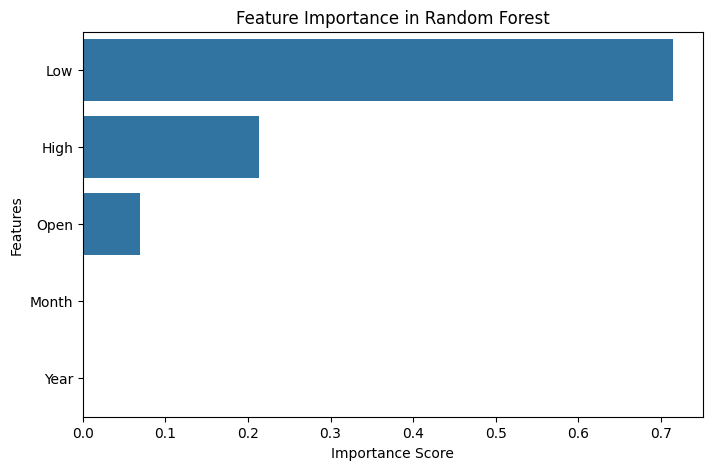

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance in Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}


In [ ]:
best_rf = grid_search.best_estimator_

In [ ]:
best_pred = best_rf.predict(X_test)

In [ ]:
print("Best Random Forest")
print("MAE:", mean_absolute_error(y_test, best_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R2 Score:", r2_score(y_test, best_pred))

Best Random Forest
MAE: 8.624940012317522
RMSE: 13.73049335843298
R2 Score: 0.9791426125265034


In [ ]:
import joblib
joblib.dump(lr_model, "yes_bank_linear_regression_model.pkl")
print("Model saved successfully!")

Model saved successfully!


# Final Conclusion

In this project, historical Yes Bank stock price data was analyzed using Exploratory Data Analysis and Machine Learning techniques.

Two regression models, Linear Regression and Random Forest, were trained and evaluated. Based on MAE, RMSE, and R² Score, Linear Regression achieved the best performance with an R² Score of 0.9907.

Therefore, Linear Regression was selected as the final model for predicting the monthly closing stock price.

This project demonstrates how machine learning can support financial forecasting and decision-making. Future improvements may include deep learning models such as LSTM, real-time stock market data integration, and deployment using Flask or Streamlit.